### 1. 환경 설정 및 상태 추적기

구글 드라이브를 연결하고, 5개의 압축 파일 경로와 학습 상태를 저장할 JSON 파일 경로를 설정합니다.

In [ ]:
import os
import json
import glob
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive', force_remount=True)

# 2. 경로 설정 (원본 데이터 경로는 동일하게, 저장 경로는 새롭게 변경)
OLD_BASE_DIR = '/content/drive/MyDrive/UNet'
NEW_BASE_DIR = '/content/drive/MyDrive/UNet_GAN' # 새로운 프로젝트 폴더

NOISE_ZIPS = glob.glob(f'{OLD_BASE_DIR}/Noise/TS_*.zip')
VOICE_ZIPS = [
    f'{OLD_BASE_DIR}/Korean_Voice/KsponSpeech_01.zip',
    f'{OLD_BASE_DIR}/Korean_Voice/KsponSpeech_02.zip',
    f'{OLD_BASE_DIR}/Korean_Voice/KsponSpeech_03.zip',
    f'{OLD_BASE_DIR}/Korean_Voice/KsponSpeech_04.zip',
    f'{OLD_BASE_DIR}/Korean_Voice/KsponSpeech_05.zip'
]

# 새로운 체크포인트 및 상태 저장 경로
CHECKPOINT_DIR = f'{NEW_BASE_DIR}/Checkpoints'
STATE_FILE = f'{CHECKPOINT_DIR}/training_state.json'

if not os.path.exists(CHECKPOINT_DIR):
    os.makedirs(CHECKPOINT_DIR)

# 3. 상태 관리 함수
def load_state():
    if os.path.exists(STATE_FILE):
        with open(STATE_FILE, 'r') as f:
            return json.load(f)
    return {"current_zip_idx": 0, "current_epoch": 0}

def save_state(zip_idx, epoch):
    state = {"current_zip_idx": zip_idx, "current_epoch": epoch}
    with open(STATE_FILE, 'w') as f:
        json.dump(state, f)
    print(f"💾 학습 상태 저장 완료: [Zip {zip_idx+1}/{len(VOICE_ZIPS)}], [Epoch {epoch}]")

print(f"새로운 GAN 환경 설정 완료 (저장 경로: {NEW_BASE_DIR})")

Mounted at /content/drive
새로운 GAN 환경 설정 완료 (저장 경로: /content/drive/MyDrive/UNet_GAN)


### 2. 모델 및 오디오 전처리 함수 (판별자 추가)
기존 U-Net(생성자)에 추가로, 스펙트로그램이 실제 사람 목소리인지 AI가 만든 것인지 구별하는 Discriminator 클래스를 추가했습니다.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- 1. 생성자 (Generator - 기존 U-Net) ---
class UNetMasker(nn.Module):
    def __init__(self):
        super(UNetMasker, self).__init__()
        self.enc1 = nn.Conv2d(1, 32, 3, padding=1)
        self.enc2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = nn.Conv2d(64, 32, 3, padding=1)
        self.dec1 = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x):
        e1 = F.relu(self.enc1(x))
        e2 = F.relu(self.enc2(self.pool(e1)))
        d2 = F.relu(self.dec2(self.up(e2)))

        if d2.size() != e1.size():
            d2 = F.interpolate(d2, size=e1.shape[2:])

        mask = torch.sigmoid(self.dec1(d2))
        return x * mask, mask

# --- 2. 판별자 (Discriminator - 신규 추가) ---
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        # 스펙트로그램 특징을 추출하여 진짜(Real)/가짜(Fake)를 판별하는 CNN 구조
        self.conv1 = nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.conv2(x), 0.2)
        x = F.leaky_relu(self.conv3(x), 0.2)
        x = F.leaky_relu(self.conv4(x), 0.2)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x # BCEWithLogitsLoss를 사용하기 위해 raw 값을 그대로 반환

# --- 3. 전처리 함수 ---
def get_spec(audio):
    window = torch.hann_window(512).to(audio.device)
    spec = torch.stft(audio.squeeze(1), n_fft=512, hop_length=160, window=window, return_complex=True, center=True)
    return torch.abs(spec), torch.angle(spec)

print("GAN 모델 (생성자 & 판별자) 및 전처리 함수 정의 완료.")

GAN 모델 (생성자 & 판별자) 및 전처리 함수 정의 완료.


### 3. 디스크 관리 및 데이터 로더 정의

압축 해제 후 삭제를 통한 디스크 용량 관리 로직과 4초 이상(128KB) 데이터 필터링 로직을 포함합니다.

In [ ]:
import glob
import zipfile
import shutil
import random
import numpy as np
import librosa
from torch.utils.data import Dataset, DataLoader

TEMP_VOICE_DIR = '/content/temp_voice'
TEMP_NOISE_DIR = '/content/temp_noise'

def manage_disk_and_extract(zip_path, extract_dir):
    if os.path.exists(extract_dir):
        shutil.rmtree(extract_dir)
        print(f"🗑️ 기존 임시 폴더 삭제 완료: {extract_dir}")

    os.makedirs(extract_dir)
    print(f"📦 압축 해제 중... ({os.path.basename(zip_path)})")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("✅ 압축 해제 완료.")

class RobustDataset(Dataset):
    def __init__(self, voice_dir, noise_dir, samples=64000):
        all_voices = glob.glob(os.path.join(voice_dir, '**', '*.pcm'), recursive=True)
        self.voice_list = [f for f in all_voices if os.path.getsize(f) >= samples * 2]

        self.noise_list = glob.glob(os.path.join(noise_dir, '**', '*.mp3'), recursive=True)
        self.samples = samples
        print(f"📊 데이터 로드: 목소리 {len(self.voice_list)}개, 소음 {len(self.noise_list)}개 준비됨.")

    def load_pcm(self, path):
        try:
            with open(path, 'rb') as f:
                return np.frombuffer(f.read(), dtype=np.int16).astype(np.float32) / 32768.0
        except:
            return np.zeros(self.samples)

    def __len__(self):
        return len(self.voice_list)

    def __getitem__(self, idx):
        v_path = self.voice_list[idx]
        v_data = self.load_pcm(v_path)
        if len(v_data) < self.samples: return torch.zeros(1, self.samples), torch.zeros(1, self.samples)

        start = np.random.randint(0, len(v_data) - self.samples + 1)
        clean = v_data[start : start + self.samples]

        n_path = random.choice(self.noise_list)
        try:
            noise, _ = librosa.load(n_path, sr=16000, offset=8.5, duration=6.0)
            # 파일이 8.5초보다 짧은 경우 처음부터 다시 로드
            if len(noise) == 0:
                noise, _ = librosa.load(n_path, sr=16000, duration=6.0)
            # 여전히 비어있으면 0으로 채움
            if len(noise) == 0:
                noise = np.zeros(self.samples)
        except:
            noise = np.zeros(self.samples)

        if len(noise) < self.samples:
            noise = np.tile(noise, int(np.ceil(self.samples / len(noise))))
        start_n = np.random.randint(0, len(noise) - self.samples + 1)
        noise = noise[start_n : start_n + self.samples]

        snr = np.random.uniform(5, 15)
        clean_rms = np.sqrt(np.mean(clean**2) + 1e-9)
        noise_rms = np.sqrt(np.mean(noise**2) + 1e-9)
        noise = noise * (clean_rms / (10**(snr/20)) / noise_rms)

        noisy = clean + noise
        return torch.FloatTensor(noisy).unsqueeze(0), torch.FloatTensor(clean).unsqueeze(0)

print("디스크 관리자 및 데이터셋 클래스 준비 완료.")

디스크 관리자 및 데이터셋 클래스 준비 완료.


### 4. 자동 복구 기반 메인 학습 루프 (적대적 학습 로직 적용)
두 모델을 동시에 학습시키며, 체크포인트 저장 및 복구 과정에서도 생성자와 판별자의 상태를 모두 기록하도록 변경되었습니다.

In [ ]:
# import torch.optim as optim
# import zipfile

# BATCH_SIZE = 64
# EPOCHS_PER_ZIP = 10
# LEARNING_RATE_G = 1e-4
# LEARNING_RATE_D = 1e-4
# LAMBDA_ADV = 0.05 # 적대적 손실(GAN Loss)의 반영 비율

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # 모델 초기화
# generator = UNetMasker().to(device)
# discriminator = Discriminator().to(device)

# # 옵티마이저 분리
# opt_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE_G)
# opt_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE_D)

# # 손실 함수
# criterion_L1 = nn.L1Loss() # 기존 MSE 대신 원본 복원에 좀 더 유리한 L1 Loss 사용
# criterion_GAN = nn.BCEWithLogitsLoss() # 판별용 손실 함수

# # 1. 상태 및 모델 복구 (Generator & Discriminator 모두 복구)
# state = load_state()
# start_zip_idx = state['current_zip_idx']
# start_epoch = state['current_epoch']

# latest_checkpoint = os.path.join(CHECKPOINT_DIR, 'latest_gan_model.pth')
# if os.path.exists(latest_checkpoint):
#     checkpoint = torch.load(latest_checkpoint, map_location=device)
#     generator.load_state_dict(checkpoint['generator_state_dict'])
#     discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
#     opt_G.load_state_dict(checkpoint['opt_G_state_dict'])
#     opt_D.load_state_dict(checkpoint['opt_D_state_dict'])
#     print(f"🔄 이전 GAN 학습 상태 복구됨. (시작 위치: Zip {start_zip_idx+1}/{len(VOICE_ZIPS)}, Epoch {start_epoch+1})")
# else:
#     print("🆕 저장된 GAN 체크포인트가 없습니다. 처음부터 학습을 시작합니다.")

# # 2. 모든 소음 데이터 압축 해제
# if not os.path.exists(TEMP_NOISE_DIR):
#     os.makedirs(TEMP_NOISE_DIR)
#     for noise_zip in NOISE_ZIPS:
#         print(f"📦 소음 압축 해제 중... ({os.path.basename(noise_zip)})")
#         with zipfile.ZipFile(noise_zip, 'r') as zip_ref:
#             zip_ref.extractall(TEMP_NOISE_DIR)
#     print("✅ 모든 소음 파일 압축 해제 완료.")

# # 3. 메인 GAN 학습 루프
# for zip_idx in range(start_zip_idx, len(VOICE_ZIPS)):
#     current_zip_path = VOICE_ZIPS[zip_idx]

#     manage_disk_and_extract(current_zip_path, TEMP_VOICE_DIR)
#     dataset = RobustDataset(TEMP_VOICE_DIR, TEMP_NOISE_DIR)
#     dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

#     epochs_to_run = range(start_epoch, EPOCHS_PER_ZIP)
#     start_epoch = 0

#     for epoch in epochs_to_run:
#         generator.train()
#         discriminator.train()

#         total_g_loss = 0
#         total_d_loss = 0

#         print(f"🚀 [Zip {zip_idx+1}/{len(VOICE_ZIPS)}] - Epoch [{epoch+1}/{EPOCHS_PER_ZIP}] 시작")

#         for i, (noisy, clean) in enumerate(dataloader):
#             noisy, clean = noisy.to(device), clean.to(device)
#             batch_size = noisy.size(0)

#             noisy_mag, _ = get_spec(noisy)
#             clean_mag, _ = get_spec(clean)
#             noisy_mag = noisy_mag.unsqueeze(1)
#             clean_mag = clean_mag.unsqueeze(1)

#             # 정답 라벨 (진짜=1, 가짜=0)
#             real_labels = torch.ones(batch_size, 1).to(device)
#             fake_labels = torch.zeros(batch_size, 1).to(device)

#             # ---------------------------------------------
#             # [1] Discriminator 학습
#             # ---------------------------------------------
#             opt_D.zero_grad()

#             # 1-1. 진짜 원본 데이터 판별
#             real_preds = discriminator(clean_mag)
#             d_loss_real = criterion_GAN(real_preds, real_labels)

#             # 1-2. Generator가 만든 가짜 데이터 판별
#             denoised_mag, _ = generator(noisy_mag)
#             fake_preds = discriminator(denoised_mag.detach()) # Generator에는 기울기가 흐르지 않도록 detach()
#             d_loss_fake = criterion_GAN(fake_preds, fake_labels)

#             d_loss = d_loss_real + d_loss_fake
#             d_loss.backward()
#             opt_D.step()

#             total_d_loss += d_loss.item()

#             # ---------------------------------------------
#             # [2] Generator 학습
#             # ---------------------------------------------
#             opt_G.zero_grad()

#             # 2-1. 원본 복원 손실 (L1 Loss)
#             g_loss_recon = criterion_L1(denoised_mag, clean_mag)

#             # 2-2. 적대적 손실 (Discriminator 속이기)
#             fake_preds_for_G = discriminator(denoised_mag)
#             g_loss_adv = criterion_GAN(fake_preds_for_G, real_labels) # 생성자의 목표는 가짜가 진짜(1)로 판별받는 것

#             # 2-3. 최종 Generator 손실
#             g_loss = g_loss_recon + (LAMBDA_ADV * g_loss_adv)
#             g_loss.backward()
#             opt_G.step()

#             total_g_loss += g_loss.item()

#             if (i+1) % 100 == 0:
#                 print(f"  Step [{i+1}/{len(dataloader)}] D_Loss: {d_loss.item():.4f} | G_Loss: {g_loss.item():.4f}")

#         # 에포크 종료 후 체크포인트 저장 (G와 D 모두 저장)
#         torch.save({
#             'generator_state_dict': generator.state_dict(),
#             'discriminator_state_dict': discriminator.state_dict(),
#             'opt_G_state_dict': opt_G.state_dict(),
#             'opt_D_state_dict': opt_D.state_dict(),
#         }, latest_checkpoint)

#         save_state(zip_idx, epoch + 1)
#         avg_d_loss = total_d_loss / len(dataloader)
#         avg_g_loss = total_g_loss / len(dataloader)
#         print(f"✅ [Zip {zip_idx+1}/{len(VOICE_ZIPS)}] - Epoch {epoch+1} 완료. (Avg D_Loss: {avg_d_loss:.4f} | Avg G_Loss: {avg_g_loss:.4f})")

# print("🎉 모든 데이터셋에 대한 GAN 학습이 완료되었습니다!")

🆕 저장된 GAN 체크포인트가 없습니다. 처음부터 학습을 시작합니다.
📦 소음 압축 해제 중... (TS_1.자연.zip)
📦 소음 압축 해제 중... (TS_10.기계 및 공구.zip)
📦 소음 압축 해제 중... (TS_2.무기.zip)
📦 소음 압축 해제 중... (TS_3.사람.zip)
📦 소음 압축 해제 중... (TS_4.동물.zip)
📦 소음 압축 해제 중... (TS_5.알람.zip)
📦 소음 압축 해제 중... (TS_6.물체.zip)
📦 소음 압축 해제 중... (TS_7.악기.zip)
📦 소음 압축 해제 중... (TS_8.군부대 운송수단.zip)
📦 소음 압축 해제 중... (TS_9.생활.zip)
✅ 모든 소음 파일 압축 해제 완료.
📦 압축 해제 중... (KsponSpeech_01.zip)
✅ 압축 해제 완료.
📊 데이터 로드: 목소리 63703개, 소음 35848개 준비됨.
🚀 [Zip 1/5] - Epoch [1/10] 시작
  Step [100/996] D_Loss: 1.3561 | G_Loss: 0.0700
  Step [200/996] D_Loss: 1.3292 | G_Loss: 0.0707
  Step [300/996] D_Loss: 1.3325 | G_Loss: 0.0734
  Step [400/996] D_Loss: 1.3389 | G_Loss: 0.0772
  Step [500/996] D_Loss: 1.3805 | G_Loss: 0.0750
  Step [600/996] D_Loss: 1.3932 | G_Loss: 0.0707
  Step [700/996] D_Loss: 1.3715 | G_Loss: 0.0724
  Step [800/996] D_Loss: 1.3951 | G_Loss: 0.0696
  Step [900/996] D_Loss: 1.3592 | G_Loss: 0.0648
💾 학습 상태 저장 완료: [Zip 1/5], [Epo

결과 검증 및 시각화

Mounted at /content/drive
✅ 불러올 모델: latest_gan_model.pth
테스트용 목소리 추출 중 (4초 이상 검색)...
테스트용 소음 추출 중...
🔊 테스트 파일 생성 완료: 목소리(KsponSpeech_102126.pcm) + 소음(S-211111_O_501_C_033_0001.mp3)


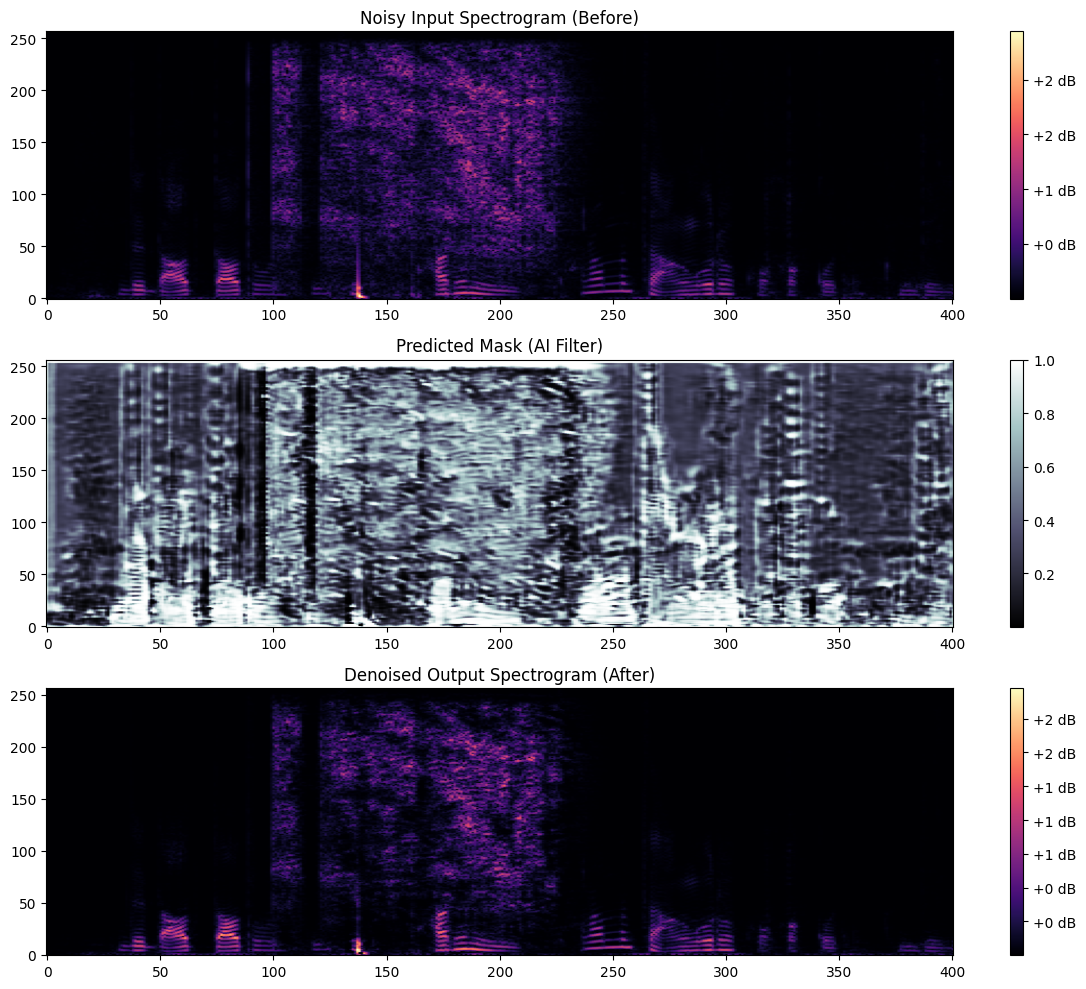

📊 스펙트로그램 이미지 저장 완료: /content/drive/MyDrive/UNet_GAN/Test_Results/result_spectrogram.png
🎧 오디오 파일 저장 완료 (noisy, denoised, clean): /content/drive/MyDrive/UNet_GAN/Test_Results 폴더 확인


In [ ]:
# import os
# import glob
# import random
# import zipfile
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import librosa
# import soundfile as sf
# import matplotlib.pyplot as plt
# from google.colab import drive

# # 1. 구글 드라이브 마운트
# drive.mount('/content/drive', force_remount=True)

# # 2. 경로 설정
# DATA_DIR = '/content/drive/MyDrive/UNet'      # 원본 데이터가 있는 폴더
# MODEL_DIR = '/content/drive/MyDrive/UNet_GAN' # GAN 모델이 저장된 폴더

# CHECKPOINT_DIR = f'{MODEL_DIR}/Checkpoints'
# RESULT_DIR = f'{MODEL_DIR}/Test_Results'

# if not os.path.exists(RESULT_DIR):
#     os.makedirs(RESULT_DIR)

# # 데이터 추출 경로는 DATA_DIR 로 연결
# VOICE_ZIP = f'{DATA_DIR}/Korean_Voice/KsponSpeech_01.zip'
# NOISE_ZIPS = glob.glob(f'{DATA_DIR}/Noise/TS_*.zip')

# # 3. 모델 및 전처리 함수 정의
# class UNetMasker(nn.Module):
#     def __init__(self):
#         super(UNetMasker, self).__init__()
#         self.enc1 = nn.Conv2d(1, 32, 3, padding=1)
#         self.enc2 = nn.Conv2d(32, 64, 3, padding=1)
#         self.pool = nn.MaxPool2d(2)
#         self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
#         self.dec2 = nn.Conv2d(64, 32, 3, padding=1)
#         self.dec1 = nn.Conv2d(32, 1, 3, padding=1)

#     def forward(self, x):
#         e1 = F.relu(self.enc1(x))
#         e2 = F.relu(self.enc2(self.pool(e1)))
#         d2 = F.relu(self.dec2(self.up(e2)))
#         if d2.size() != e1.size():
#             d2 = F.interpolate(d2, size=e1.shape[2:])
#         mask = torch.sigmoid(self.dec1(d2))
#         return x * mask, mask

# def get_spec(audio):
#     window = torch.hann_window(512).to(audio.device)
#     spec = torch.stft(audio.squeeze(1), n_fft=512, hop_length=160, window=window, return_complex=True, center=True)
#     return torch.abs(spec), torch.angle(spec)

# def spec_to_wav(mag, phase):
#     complex_spec = torch.polar(mag, phase)
#     return torch.istft(complex_spec, n_fft=512, hop_length=160, center=True)

# # 4. 테스트용 샘플 추출 함수
# def get_random_test_samples(voice_zip, noise_zips, temp_dir='/content/temp_test'):
#     if not os.path.exists(temp_dir): os.makedirs(temp_dir)

#     print("테스트용 목소리 추출 중 (4초 이상 검색)...")
#     with zipfile.ZipFile(voice_zip, 'r') as z:
#         min_bytes = 16000 * 2 * 4
#         valid_infos = [info for info in z.infolist() if info.filename.endswith('.pcm') and info.file_size >= min_bytes]
#         target_info = random.choice(valid_infos)
#         z.extract(target_info, temp_dir)
#         voice_path = os.path.join(temp_dir, target_info.filename)

#     print("테스트용 소음 추출 중...")
#     noise_zip = random.choice(noise_zips)
#     with zipfile.ZipFile(noise_zip, 'r') as z:
#         mp3_files = [f for f in z.namelist() if f.endswith('.mp3')]
#         target_mp3 = random.choice(mp3_files)
#         z.extract(target_mp3, temp_dir)
#         noise_path = os.path.join(temp_dir, target_mp3)

#     return voice_path, noise_path

# # 5. 메인 실행 및 시각화 로직
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# latest_checkpoint = os.path.join(CHECKPOINT_DIR, 'latest_gan_model.pth')
# if not os.path.exists(latest_checkpoint):
#     print(f"❌ 오류: {latest_checkpoint} 파일이 없습니다. 학습이 완료되었는지 확인하세요.")
# else:
#     print(f"✅ 불러올 모델: {os.path.basename(latest_checkpoint)}")

#     model = UNetMasker().to(device)
#     checkpoint = torch.load(latest_checkpoint, map_location=device)
#     model.load_state_dict(checkpoint['generator_state_dict'])
#     model.eval()

#     v_path, n_path = get_random_test_samples(VOICE_ZIP, NOISE_ZIPS)

#     with open(v_path, 'rb') as f:
#         clean = np.frombuffer(f.read(), dtype=np.int16).astype(np.float32) / 32768.0

#     try:
#         noise, _ = librosa.load(n_path, sr=16000, offset=8.5, duration=6.0)
#         if len(noise) == 0:
#             noise, _ = librosa.load(n_path, sr=16000, duration=6.0)
#         if len(noise) == 0:
#             noise = np.zeros(16000 * 4)
#     except:
#         noise = np.zeros(16000 * 4)

#     sample_len = 16000 * 4
#     clean = clean[:sample_len]

#     if len(noise) >= sample_len:
#         noise = noise[:sample_len]
#     else:
#         noise = np.resize(noise, sample_len)

#     noisy = clean + noise * 0.5
#     print(f"🔊 테스트 파일 생성 완료: 목소리({os.path.basename(v_path)}) + 소음({os.path.basename(n_path)})")

#     with torch.no_grad():
#         noisy_t = torch.FloatTensor(noisy).unsqueeze(0).unsqueeze(0)
#         mag, phase = get_spec(noisy_t)

#         mag = mag.unsqueeze(1).to(device)

#         denoised_mag, mask = model(mag)
#         denoised_wav = spec_to_wav(denoised_mag.squeeze(1).cpu(), phase)

#     plt.figure(figsize=(12, 10))

#     plt.subplot(3, 1, 1)
#     plt.title("Noisy Input Spectrogram (Before)")
#     plt.imshow(torch.log1p(mag.squeeze().cpu()).numpy(), aspect='auto', origin='lower', cmap='magma')
#     plt.colorbar(format='%+2.0f dB')

#     plt.subplot(3, 1, 2)
#     plt.title("Predicted Mask (AI Filter)")
#     plt.imshow(mask.squeeze().cpu().numpy(), aspect='auto', origin='lower', cmap='bone')
#     plt.colorbar()

#     plt.subplot(3, 1, 3)
#     plt.title("Denoised Output Spectrogram (After)")
#     plt.imshow(torch.log1p(denoised_mag.squeeze().cpu()).numpy(), aspect='auto', origin='lower', cmap='magma')
#     plt.colorbar(format='%+2.0f dB')

#     plt.tight_layout()

#     save_img_path = os.path.join(RESULT_DIR, 'result_spectrogram.png')
#     plt.savefig(save_img_path)
#     plt.show()
#     print(f"📊 스펙트로그램 이미지 저장 완료: {save_img_path}")

#     sf.write(os.path.join(RESULT_DIR, 'test_noisy.wav'), noisy, 16000)
#     sf.write(os.path.join(RESULT_DIR, 'test_denoised.wav'), denoised_wav[0].numpy(), 16000)
#     sf.write(os.path.join(RESULT_DIR, 'test_clean.wav'), clean, 16000)
#     print(f"🎧 오디오 파일 저장 완료 (noisy, denoised, clean): {RESULT_DIR} 폴더 확인")

4-1. 파라미터, 손실함수 조절하여 처음부터 다시 학습

In [ ]:
import torch.optim as optim
import zipfile

BATCH_SIZE = 64
EPOCHS_PER_ZIP = 10
LEARNING_RATE_G = 1e-4
LEARNING_RATE_D = 1e-5 # 판별자의 학습 속도를 생성자의 1/10로 낮춰 밸런스 조절
LAMBDA_ADV = 0.05 # 적대적 손실(GAN Loss)의 반영 비율

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 모델 초기화
generator = UNetMasker().to(device)
discriminator = Discriminator().to(device)

# 옵티마이저 분리
opt_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE_G)
opt_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE_D)

# 손실 함수
criterion_L1 = nn.L1Loss() # 기존 MSE 대신 원본 복원에 좀 더 유리한 L1 Loss 사용
# criterion_GAN = nn.BCEWithLogitsLoss() # 판별용 손실 함수
criterion_GAN = nn.MSELoss() # BCE 대신 안정적인 학습을 돕는 MSELoss (LSGAN 방식) 적용

# 1. 상태 및 모델 복구 (Generator & Discriminator 모두 복구)
state = load_state()
start_zip_idx = state['current_zip_idx']
start_epoch = state['current_epoch']

latest_checkpoint = os.path.join(CHECKPOINT_DIR, 'latest_gan_model.pth')
if os.path.exists(latest_checkpoint):
    checkpoint = torch.load(latest_checkpoint, map_location=device)
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    opt_G.load_state_dict(checkpoint['opt_G_state_dict'])
    opt_D.load_state_dict(checkpoint['opt_D_state_dict'])
    print(f"🔄 이전 GAN 학습 상태 복구됨. (시작 위치: Zip {start_zip_idx+1}/{len(VOICE_ZIPS)}, Epoch {start_epoch+1})")
else:
    print("🆕 저장된 GAN 체크포인트가 없습니다. 처음부터 학습을 시작합니다.")

# 2. 모든 소음 데이터 압축 해제
if not os.path.exists(TEMP_NOISE_DIR):
    os.makedirs(TEMP_NOISE_DIR)
    for noise_zip in NOISE_ZIPS:
        print(f"📦 소음 압축 해제 중... ({os.path.basename(noise_zip)})")
        with zipfile.ZipFile(noise_zip, 'r') as zip_ref:
            zip_ref.extractall(TEMP_NOISE_DIR)
    print("✅ 모든 소음 파일 압축 해제 완료.")

# 3. 메인 GAN 학습 루프
for zip_idx in range(start_zip_idx, len(VOICE_ZIPS)):
    current_zip_path = VOICE_ZIPS[zip_idx]

    manage_disk_and_extract(current_zip_path, TEMP_VOICE_DIR)
    dataset = RobustDataset(TEMP_VOICE_DIR, TEMP_NOISE_DIR)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

    epochs_to_run = range(start_epoch, EPOCHS_PER_ZIP)
    start_epoch = 0

    for epoch in epochs_to_run:
        generator.train()
        discriminator.train()

        total_g_loss = 0
        total_d_loss = 0

        print(f"🚀 [Zip {zip_idx+1}/{len(VOICE_ZIPS)}] - Epoch [{epoch+1}/{EPOCHS_PER_ZIP}] 시작")

        for i, (noisy, clean) in enumerate(dataloader):
            noisy, clean = noisy.to(device), clean.to(device)
            batch_size = noisy.size(0)

            noisy_mag, _ = get_spec(noisy)
            clean_mag, _ = get_spec(clean)
            noisy_mag = noisy_mag.unsqueeze(1)
            clean_mag = clean_mag.unsqueeze(1)

            # 정답 라벨 (진짜=1, 가짜=0)
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # ---------------------------------------------
            # [1] Discriminator 학습
            # ---------------------------------------------
            opt_D.zero_grad()

            # 1-1. 진짜 원본 데이터 판별
            real_preds = discriminator(clean_mag)
            d_loss_real = criterion_GAN(real_preds, real_labels)

            # 1-2. Generator가 만든 가짜 데이터 판별
            denoised_mag, _ = generator(noisy_mag)
            fake_preds = discriminator(denoised_mag.detach()) # Generator에는 기울기가 흐르지 않도록 detach()
            d_loss_fake = criterion_GAN(fake_preds, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            opt_D.step()

            total_d_loss += d_loss.item()

            # ---------------------------------------------
            # [2] Generator 학습
            # ---------------------------------------------
            opt_G.zero_grad()

            # 2-1. 원본 복원 손실 (L1 Loss)
            g_loss_recon = criterion_L1(denoised_mag, clean_mag)

            # 2-2. 적대적 손실 (Discriminator 속이기)
            fake_preds_for_G = discriminator(denoised_mag)
            g_loss_adv = criterion_GAN(fake_preds_for_G, real_labels) # 생성자의 목표는 가짜가 진짜(1)로 판별받는 것

            # 2-3. 최종 Generator 손실
            g_loss = g_loss_recon + (LAMBDA_ADV * g_loss_adv)
            g_loss.backward()
            opt_G.step()

            total_g_loss += g_loss.item()

            if (i+1) % 100 == 0:
                print(f"  Step [{i+1}/{len(dataloader)}] D_Loss: {d_loss.item():.4f} | G_Loss: {g_loss.item():.4f}")

        # 에포크 종료 후 체크포인트 저장 (G와 D 모두 저장)
        torch.save({
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'opt_G_state_dict': opt_G.state_dict(),
            'opt_D_state_dict': opt_D.state_dict(),
        }, latest_checkpoint)

        save_state(zip_idx, epoch + 1)
        avg_d_loss = total_d_loss / len(dataloader)
        avg_g_loss = total_g_loss / len(dataloader)
        print(f"✅ [Zip {zip_idx+1}/{len(VOICE_ZIPS)}] - Epoch {epoch+1} 완료. (Avg D_Loss: {avg_d_loss:.4f} | Avg G_Loss: {avg_g_loss:.4f})")

print("🎉 모든 데이터셋에 대한 GAN 학습이 완료되었습니다!")

🆕 저장된 GAN 체크포인트가 없습니다. 처음부터 학습을 시작합니다.
📦 소음 압축 해제 중... (TS_1.자연.zip)
📦 소음 압축 해제 중... (TS_10.기계 및 공구.zip)
📦 소음 압축 해제 중... (TS_2.무기.zip)
📦 소음 압축 해제 중... (TS_3.사람.zip)
📦 소음 압축 해제 중... (TS_4.동물.zip)
📦 소음 압축 해제 중... (TS_5.알람.zip)
📦 소음 압축 해제 중... (TS_6.물체.zip)
📦 소음 압축 해제 중... (TS_7.악기.zip)
📦 소음 압축 해제 중... (TS_8.군부대 운송수단.zip)
📦 소음 압축 해제 중... (TS_9.생활.zip)
✅ 모든 소음 파일 압축 해제 완료.
📦 압축 해제 중... (KsponSpeech_01.zip)
✅ 압축 해제 완료.
📊 데이터 로드: 목소리 63703개, 소음 35848개 준비됨.
🚀 [Zip 1/5] - Epoch [1/10] 시작
  Step [100/996] D_Loss: 0.6448 | G_Loss: 0.0627
  Step [200/996] D_Loss: 0.5161 | G_Loss: 0.0512
  Step [300/996] D_Loss: 0.5083 | G_Loss: 0.0471
  Step [400/996] D_Loss: 0.5073 | G_Loss: 0.0548
  Step [500/996] D_Loss: 0.5004 | G_Loss: 0.0433
  Step [600/996] D_Loss: 0.4993 | G_Loss: 0.0431
  Step [700/996] D_Loss: 0.4993 | G_Loss: 0.0407
  Step [800/996] D_Loss: 0.4984 | G_Loss: 0.0406
  Step [900/996] D_Loss: 0.4981 | G_Loss: 0.0416
💾 학습 상태 저장 완료: [Zip 1/5], [Epo

Mounted at /content/drive
✅ 불러올 모델: latest_gan_model.pth
테스트용 목소리 추출 중 (4초 이상 검색)...
테스트용 소음 추출 중...
🔊 테스트 파일 생성 완료: 목소리(KsponSpeech_103388.pcm) + 소음(S-211029_M_202_C_017_0001.mp3)


/tmp/ipykernel_176/1137129125.py:58: UserWarning: A window was not provided. A rectangular window will be applied.Please provide the same window used by stft to make the inversion lossless.To suppress this warning and use a rectangular window, explicitly set `window=torch.ones(n_fft, device=<device>)`. (Triggered internally at /pytorch/aten/src/ATen/native/SpectralOps.cpp:1035.)
  return torch.istft(complex_spec, n_fft=512, hop_length=160, center=True)


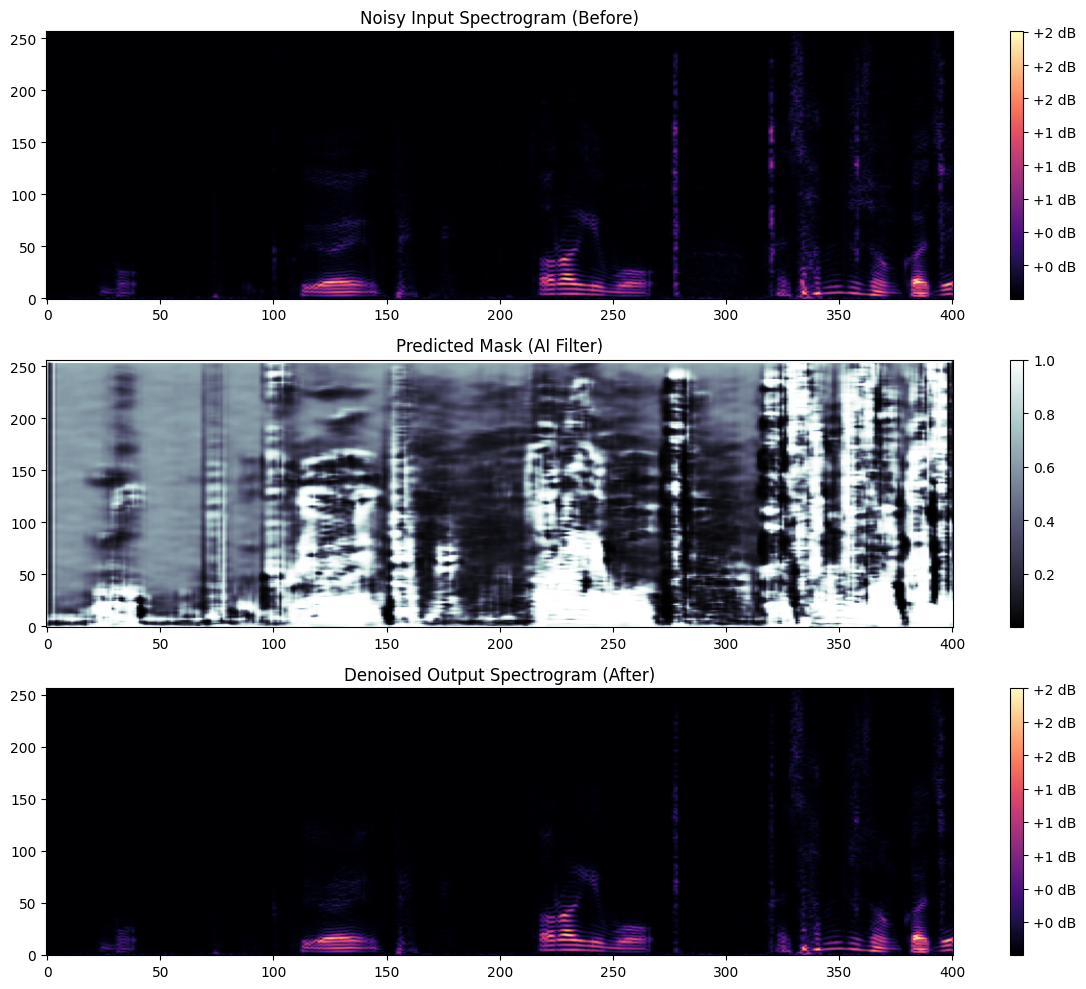

📊 스펙트로그램 이미지 저장 완료: /content/drive/MyDrive/UNet_GAN/Test_Results/result_spectrogram.png
🎧 오디오 파일 저장 완료 (noisy, denoised, clean): /content/drive/MyDrive/UNet_GAN/Test_Results 폴더 확인


In [1]:
import os
import glob
import random
import zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive', force_remount=True)

# 2. 경로 설정
DATA_DIR = '/content/drive/MyDrive/UNet'      # 원본 데이터가 있는 폴더
MODEL_DIR = '/content/drive/MyDrive/UNet_GAN' # GAN 모델이 저장된 폴더

CHECKPOINT_DIR = f'{MODEL_DIR}/Checkpoints'
RESULT_DIR = f'{MODEL_DIR}/Test_Results'

if not os.path.exists(RESULT_DIR):
    os.makedirs(RESULT_DIR)

# 데이터 추출 경로는 DATA_DIR 로 연결
VOICE_ZIP = f'{DATA_DIR}/Korean_Voice/KsponSpeech_01.zip'
NOISE_ZIPS = glob.glob(f'{DATA_DIR}/Noise/TS_*.zip')

# 3. 모델 및 전처리 함수 정의
class UNetMasker(nn.Module):
    def __init__(self):
        super(UNetMasker, self).__init__()
        self.enc1 = nn.Conv2d(1, 32, 3, padding=1)
        self.enc2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = nn.Conv2d(64, 32, 3, padding=1)
        self.dec1 = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x):
        e1 = F.relu(self.enc1(x))
        e2 = F.relu(self.enc2(self.pool(e1)))
        d2 = F.relu(self.dec2(self.up(e2)))
        if d2.size() != e1.size():
            d2 = F.interpolate(d2, size=e1.shape[2:])
        mask = torch.sigmoid(self.dec1(d2))
        return x * mask, mask

def get_spec(audio):
    window = torch.hann_window(512).to(audio.device)
    spec = torch.stft(audio.squeeze(1), n_fft=512, hop_length=160, window=window, return_complex=True, center=True)
    return torch.abs(spec), torch.angle(spec)

def spec_to_wav(mag, phase):
    complex_spec = torch.polar(mag, phase)
    return torch.istft(complex_spec, n_fft=512, hop_length=160, center=True)

# 4. 테스트용 샘플 추출 함수
def get_random_test_samples(voice_zip, noise_zips, temp_dir='/content/temp_test'):
    if not os.path.exists(temp_dir): os.makedirs(temp_dir)

    print("테스트용 목소리 추출 중 (4초 이상 검색)...")
    with zipfile.ZipFile(voice_zip, 'r') as z:
        min_bytes = 16000 * 2 * 4
        valid_infos = [info for info in z.infolist() if info.filename.endswith('.pcm') and info.file_size >= min_bytes]
        target_info = random.choice(valid_infos)
        z.extract(target_info, temp_dir)
        voice_path = os.path.join(temp_dir, target_info.filename)

    print("테스트용 소음 추출 중...")
    noise_zip = random.choice(noise_zips)
    with zipfile.ZipFile(noise_zip, 'r') as z:
        mp3_files = [f for f in z.namelist() if f.endswith('.mp3')]
        target_mp3 = random.choice(mp3_files)
        z.extract(target_mp3, temp_dir)
        noise_path = os.path.join(temp_dir, target_mp3)

    return voice_path, noise_path

# 5. 메인 실행 및 시각화 로직
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

latest_checkpoint = os.path.join(CHECKPOINT_DIR, 'latest_gan_model.pth')
if not os.path.exists(latest_checkpoint):
    print(f"❌ 오류: {latest_checkpoint} 파일이 없습니다. 학습이 완료되었는지 확인하세요.")
else:
    print(f"✅ 불러올 모델: {os.path.basename(latest_checkpoint)}")

    model = UNetMasker().to(device)
    checkpoint = torch.load(latest_checkpoint, map_location=device)
    model.load_state_dict(checkpoint['generator_state_dict'])
    model.eval()

    v_path, n_path = get_random_test_samples(VOICE_ZIP, NOISE_ZIPS)

    with open(v_path, 'rb') as f:
        clean = np.frombuffer(f.read(), dtype=np.int16).astype(np.float32) / 32768.0

    try:
        noise, _ = librosa.load(n_path, sr=16000, offset=8.5, duration=6.0)
        if len(noise) == 0:
            noise, _ = librosa.load(n_path, sr=16000, duration=6.0)
        if len(noise) == 0:
            noise = np.zeros(16000 * 4)
    except:
        noise = np.zeros(16000 * 4)

    sample_len = 16000 * 4
    clean = clean[:sample_len]

    if len(noise) >= sample_len:
        noise = noise[:sample_len]
    else:
        noise = np.resize(noise, sample_len)

    noisy = clean + noise * 0.5
    print(f"🔊 테스트 파일 생성 완료: 목소리({os.path.basename(v_path)}) + 소음({os.path.basename(n_path)})")

    with torch.no_grad():
        noisy_t = torch.FloatTensor(noisy).unsqueeze(0).unsqueeze(0)
        mag, phase = get_spec(noisy_t)

        mag = mag.unsqueeze(1).to(device)

        denoised_mag, mask = model(mag)
        denoised_wav = spec_to_wav(denoised_mag.squeeze(1).cpu(), phase)

    plt.figure(figsize=(12, 10))

    plt.subplot(3, 1, 1)
    plt.title("Noisy Input Spectrogram (Before)")
    plt.imshow(torch.log1p(mag.squeeze().cpu()).numpy(), aspect='auto', origin='lower', cmap='magma')
    plt.colorbar(format='%+2.0f dB')

    plt.subplot(3, 1, 2)
    plt.title("Predicted Mask (AI Filter)")
    plt.imshow(mask.squeeze().cpu().numpy(), aspect='auto', origin='lower', cmap='bone')
    plt.colorbar()

    plt.subplot(3, 1, 3)
    plt.title("Denoised Output Spectrogram (After)")
    plt.imshow(torch.log1p(denoised_mag.squeeze().cpu()).numpy(), aspect='auto', origin='lower', cmap='magma')
    plt.colorbar(format='%+2.0f dB')

    plt.tight_layout()

    save_img_path = os.path.join(RESULT_DIR, 'result_spectrogram.png')
    plt.savefig(save_img_path)
    plt.show()
    print(f"📊 스펙트로그램 이미지 저장 완료: {save_img_path}")

    sf.write(os.path.join(RESULT_DIR, 'test_noisy.wav'), noisy, 16000)
    sf.write(os.path.join(RESULT_DIR, 'test_denoised.wav'), denoised_wav[0].numpy(), 16000)
    sf.write(os.path.join(RESULT_DIR, 'test_clean.wav'), clean, 16000)
    print(f"🎧 오디오 파일 저장 완료 (noisy, denoised, clean): {RESULT_DIR} 폴더 확인")